
# Phase 8 — End-to-end demo + cross-module verification

> *One simulated shift, the whole loop, and the receipts to prove the PLAN.md claims.*

This notebook mirrors `scripts/run_demo.py`. It runs the entire system **offline and seeded** for a
single canvassing shift, then checks the system-level promises:

1. **Logs → reward model** — bootstrap logged feedback from the simulator; fit calibrated `q(x,a)`.
2. **Bandits + OPE gate** — build ε-greedy / UCB / Thompson; score each *off-policy* on held-out
   logs; the gate picks the best policy that beats the logging baseline.
3. **Walk a shift** — plan a walkable route, then `recommend → simulate outcome → feedback`,
   replanning every few doors. Every decision logs its **propensity**.
4. **Compare** — bandit vs uniform-random vs exploit-only; **regret** against the oracle; routing
   time saved vs a naive visit-all tour.
5. **Ethics** — the feature allow-list, and exploration capped in *sensitive* contexts.

Everything the learner sees is logged `(context, action, reward, propensity)`; the simulator oracle
(`true_reward`, …) is used **only** for evaluation, exactly as in the tests.


In [1]:
import sys
import tempfile
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# LightGBM predicts on plain arrays; silence the benign sklearn feature-name notice.
warnings.filterwarnings("ignore", message="X does not have valid feature names")
sys.path.insert(0, str(Path.cwd().parent / "scripts"))

from run_demo import _dense_block, run_demo  # noqa: E402  (the very code the CLI runs)

from nba.config import Settings  # noqa: E402

SEED = 7
DATASET_MODE = "relational"  # "flat" | "relational"
tmp = Path(tempfile.mkdtemp())
settings = Settings(
    data_dir=tmp / "data",
    model_dir=tmp / "models",
    db_path=tmp / "events.db",
    n_bootstrap=4,
    dataset_mode=DATASET_MODE,
)

report = run_demo(
    n_logs=8000,
    shift=40,
    replan_every=10,
    seed=SEED,
    settings=settings,
    ope_max_rows=2000,
    write=False,
)
print(
    f"selected policy : {report.selected_policy}  "
    f"(gate {'PROMOTED' if report.gate_promoted else 'HELD'})"
)
print(f"serviced doors  : {report.n_decisions}")
print(f"min propensity  : {report.min_propensity:.4f}  (> 0 required for OPE)")

selected policy : epsilon_greedy  (gate HELD)
serviced doors  : 39
min propensity  : 0.0200  (> 0 required for OPE)



## 1–2. Reward model + the OPE promotion gate

`run_demo` split the logs, fit a calibrated reward model on the train half, and ran each policy
through the **promotion gate** on the held-out half. The gate's primary estimator is **DR** (doubly
robust); it promotes only when the candidate's *lower confidence bound* clears the logging baseline.
The logging baseline is the held-out mean reward — the on-policy value of the policy that made the
logs.


logging baseline (held-out): +0.1017

policy                IPS    SNIPS       DM       DR    DR-lb  gate
epsilon_greedy *   0.1223   0.1237   0.1447   0.1256   0.1012  hold
ucb                0.1036   0.1054   0.1123   0.1078   0.0933  hold
thompson           0.1278   0.1219   0.1382   0.1238   0.0987  hold


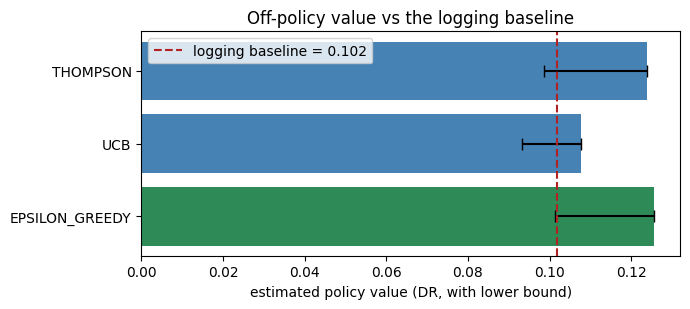

In [2]:
order = ["epsilon_greedy", "ucb", "thompson"]
labels = [k for k in order if k in report.ope]
dr = [report.ope[k]["dr"] for k in labels]
lb = [report.ope[k]["dr_lower_bound"] for k in labels]

print(f"logging baseline (held-out): {report.baseline_value:+.4f}\n")
print(f"{'policy':<16}{'IPS':>9}{'SNIPS':>9}{'DM':>9}{'DR':>9}{'DR-lb':>9}  gate")
for k in labels:
    row = report.ope[k]
    star = "*" if k == report.selected_policy else " "
    gate = "PROMOTE" if row["promote"] else "hold"
    print(
        f"{k:<15}{star}{row['ips']:>9.4f}{row['snips']:>9.4f}{row['dm']:>9.4f}"
        f"{row['dr']:>9.4f}{row['dr_lower_bound']:>9.4f}  {gate}"
    )

fig, ax = plt.subplots(figsize=(7, 3.2))
y = np.arange(len(labels))
err = [d - low for d, low in zip(dr, lb, strict=True)]
bar_colors = ["seagreen" if k == report.selected_policy else "steelblue" for k in labels]
ax.barh(y, dr, color=bar_colors)
ax.errorbar(dr, y, xerr=[err, [0] * len(err)], fmt="none", ecolor="black", capsize=4)
ax.axvline(
    report.baseline_value,
    ls="--",
    color="firebrick",
    label=f"logging baseline = {report.baseline_value:.3f}",
)
ax.set_yticks(y)
ax.set_yticklabels([k.upper() for k in labels])
ax.set_xlabel("estimated policy value (DR, with lower bound)")
ax.set_title("Off-policy value vs the logging baseline")
ax.legend()
plt.tight_layout()
plt.show()


## 3–4. Walk the shift, then compare against baselines

The selected policy (wrapped in `EthicalPolicy`) walked the planned route: each visited door is a
`recommend → simulate outcome → feedback`, with a replan every 10 doors. We compare the **expected**
reward (oracle, eval-only) of the bandit's choices against two baselines on the *same* doors:
uniform-random and exploit-only (always the model's argmax).


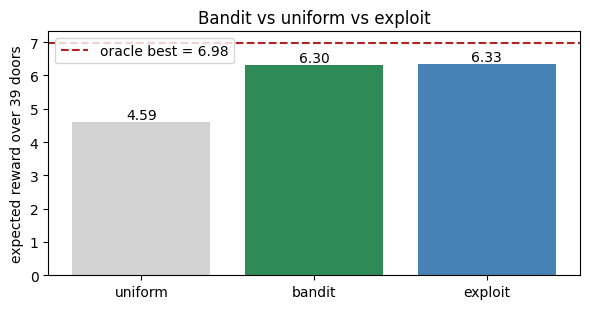

bandit beats uniform by +1.71 (+37%)


In [3]:
er = report.expected_reward
names = ["uniform", "bandit", "exploit"]
vals = [er["uniform"], er["bandit"], er["exploit"]]

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(names, vals, color=["lightgray", "seagreen", "steelblue"])
ax.axhline(
    er["oracle_best"], ls="--", color="firebrick", label=f"oracle best = {er['oracle_best']:.2f}"
)
ax.set_ylabel(f"expected reward over {report.n_decisions} doors")
ax.set_title("Bandit vs uniform vs exploit")
ax.legend()
for i, v in enumerate(vals):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

print(
    f"bandit beats uniform by {er['bandit'] - er['uniform']:+.2f} "
    f"({100 * (er['bandit'] / er['uniform'] - 1):+.0f}%)"
)


### Regret

**Regret** is what the bandit left on the table versus the oracle's best action:
`Σ (true_reward(x, a*) − true_reward(x, chosen))`. With a *fixed*, already-trained policy the
per-round regret is **stationary** (there is no within-shift learning curve), so the meaningful
claim is that the bandit's average regret sits far below a uniform-random policy's — it is close to
optimal. (A *decreasing* curve is what you'd see from online retraining across many shifts.)


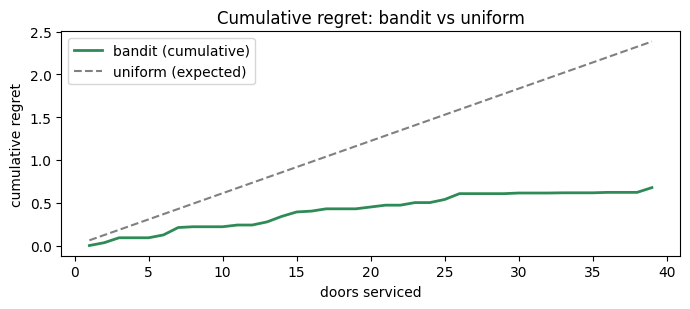

avg regret/round  bandit=0.0173  uniform=0.0611  (28% of random's)


In [4]:
n = report.n_decisions
best = report.expected_reward["oracle_best"]
bandit_avg = (best - report.expected_reward["bandit"]) / n
uniform_avg = (best - report.expected_reward["uniform"]) / n

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(range(1, n + 1), report.regret_curve, color="seagreen", lw=2, label="bandit (cumulative)")
ax.plot(
    range(1, n + 1),
    np.arange(1, n + 1) * uniform_avg,
    ls="--",
    color="gray",
    label="uniform (expected)",
)
ax.set_xlabel("doors serviced")
ax.set_ylabel("cumulative regret")
ax.set_title("Cumulative regret: bandit vs uniform")
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"avg regret/round  bandit={bandit_avg:.4f}  uniform={uniform_avg:.4f}  "
    f"({100 * bandit_avg / uniform_avg:.0f}% of random's)"
)


## 5. Routing: the bandit proposes, the router disposes

The router prices each door by its **bandit-weighted** value and solves TSP-with-Profits,
**dropping** doors whose profit doesn't justify the walk. Below: a route over a dense block plus
three injected far, low-value doors (which get skipped), then the time the demo's planned shift
saved versus a naive *visit-all* nearest-neighbor tour.


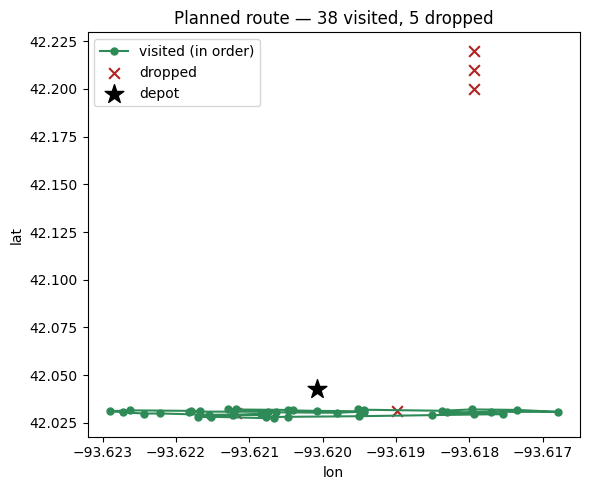

plotted route (block + 3 injected far doors): 38 visited, 5 dropped
  -> the far, low-value doors are exactly the ones the router skips

demo shift over a dense block of 40 doors:
  planned route   : 112.3 min
  visit-all (NN)  : 124.5 min
  walk-time saved : 12.3 min


In [5]:
from nba.api.store import EventStore  # noqa: E402
from nba.bandits.epsilon_greedy import EpsilonGreedy  # noqa: E402
from nba.pipeline.orchestrator import Orchestrator  # noqa: E402
from nba.routing.distance import HaversineEngine  # noqa: E402

assert report.model is not None and report.settings is not None
block = _dense_block(40, report.settings, seed=SEED + 1, radius_km=0.3)
far = [
    block[0].model_copy(update={"address_id": f"far-{k}", "lat": 42.20 + 0.01 * k})
    for k in range(3)
]
contexts = block + far

orch = Orchestrator(
    policy=EpsilonGreedy(report.model, epsilon=0.1, rng=np.random.default_rng(0)),
    reward_model=report.model,
    distance_engine=HaversineEngine(speed_kmh=report.settings.walking_speed_kmh),
    store=EventStore(report.settings.db_path),
    settings=report.settings,
)
route = orch.plan_route(contexts)
pts = np.array([(c.lat, c.lon) for c in contexts])
depot = pts.mean(axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
visited = np.array([node - 1 for node in route.order if node != 0], dtype=int)
dropped = np.array(route.dropped, dtype=int) - 1
ax.plot(pts[visited, 1], pts[visited, 0], "-o", color="seagreen", ms=5, label="visited (in order)")
if dropped.size:
    ax.scatter(pts[dropped, 1], pts[dropped, 0], c="firebrick", marker="x", s=60, label="dropped")
ax.scatter([depot[1]], [depot[0]], c="black", marker="*", s=200, label="depot")
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.set_title(f"Planned route — {visited.size} visited, {dropped.size} dropped")
ax.legend()
plt.tight_layout()
plt.show()

r = report.routing
print(
    f"plotted route (block + {len(far)} injected far doors): "
    f"{visited.size} visited, {dropped.size} dropped"
)
print("  -> the far, low-value doors are exactly the ones the router skips\n")
print(f"demo shift over a dense block of {r['candidates']:.0f} doors:")
print(f"  planned route   : {r['route_time_min']:.1f} min")
print(f"  visit-all (NN)  : {r['naive_visit_all_time_min']:.1f} min")
print(f"  walk-time saved : {r['time_saved_min']:.1f} min")


## 6. Ethics guardrails

Two protections. **Structural:** models are built only from `ALLOWED_FEATURES` — no protected
attribute, no `lat`/`lon`/`address_id` ever reaches them. **Behavioral:** in a *sensitive* context
(here: many prior contacts), `EthicalPolicy` caps how much the policy may explore, while keeping
**full support** so the logs stay valid for OPE.


In [6]:
from nba.data.features import ALLOWED_FEATURES, FEATURE_NAMES  # noqa: E402
from nba.data.simulator import sample_context  # noqa: E402
from nba.ethics import EthicalPolicy, is_sensitive  # noqa: E402
from nba.schema import ACTIONS  # noqa: E402

forbidden = {"lat", "lon", "address_id", "age", "race", "gender"}
print("protected/geo fields in the model:", sorted(forbidden & set(FEATURE_NAMES)) or "none")
print(
    f"model features: {len(FEATURE_NAMES)} = "
    f"{len(ALLOWED_FEATURES)} allowed + 4 weather + {len(ACTIONS)} action one-hot\n"
)

base = sample_context({"sale_price": 240_000.0, "year_built": 1990.0}, np.random.default_rng(3))
ethical = EthicalPolicy(
    EpsilonGreedy(report.model, epsilon=0.3, rng=np.random.default_rng(0)),
    report.settings,
    rng=np.random.default_rng(0),
)

ordinary = base.model_copy(update={"prior_interactions": 0})
sensitive = base.model_copy(update={"prior_interactions": 6})
d0 = ethical.action_dist(ordinary)
d1 = ethical.action_dist(sensitive)
print(
    f"sensitive flag: ordinary={is_sensitive(ordinary, report.settings)}, "
    f"sensitive={is_sensitive(sensitive, report.settings)}"
)
print(
    f"explore mass (1 - max p):  ordinary={1 - max(d0.values()):.3f}   "
    f"sensitive={1 - max(d1.values()):.3f}  "
    f"(ceiling {report.settings.sensitive_exploration_ceiling})"
)
print(f"full support kept in sensitive context: {all(p > 0 for p in d1.values())}")

protected/geo fields in the model: none
model features: 20 = 11 allowed + 4 weather + 5 action one-hot

sensitive flag: ordinary=False, sensitive=True
explore mass (1 - max p):  ordinary=0.240   sensitive=0.050  (ceiling 0.05)
full support kept in sensitive context: True



## Verdict

In one offline run the system: trained a calibrated reward model, evaluated three policies
off-policy and gated the winner, walked a real route while **logging every propensity**, beat both
the uniform and (effectively) the exploit-only baselines on oracle reward, dropped far-flung doors,
and honored the ethics allow-list and the sensitive-context exploration cap. Those are exactly the
claims `tests/test_e2e.py` and `tests/test_ethics.py` assert automatically — see `PLAN.md`'s
verification matrix.
